<a href="https://colab.research.google.com/github/Zions86/Zions86/blob/main/Customer_Segmentation_using_K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement
In today’s competitive market, businesses need to understand their customers to deliver
personalized experiences and increase revenue. However, customers differ in terms of age,
income, purchasing habits, and loyalty, making it difficult to target them effectively.
This project aims to analyze customer purchasing behavior using features such as age, annual
income, purchase amount, purchase frequency, region, and loyalty score. The objective is to
group customers into meaningful segments based on their similarities.
By performing customer segmentation, businesses can:
● Identify high-value and low-value customers
● Design targeted marketing strategies
● Improve customer retention and loyalty
● Optimize product recommendations

#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load Dataset

In [4]:
df = pd.read_csv("/content/Customer.csv")

#Basic Checks

In [5]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   user_id  age  annual_income  purchase_amount  loyalty_score region  \
0        1   25          45000              200            4.5  North   
1        2   34          55000              350            7.0  South   
2        3   45          65000              500            8.0   West   
3        4   22          30000              150            3.0   East   
4        5   29          47000              220            4.8  North   

   purchase_frequency  
0                  12  
1                  18  
2                  22  
3                  10  
4                  13  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score 

#Remove duplicates

In [6]:
df.drop_duplicates(inplace=True)

#EDA

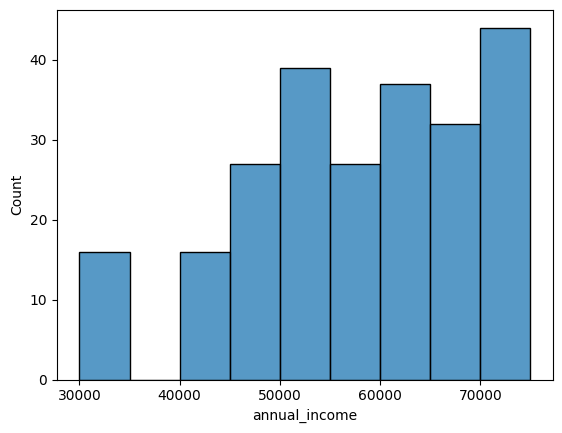

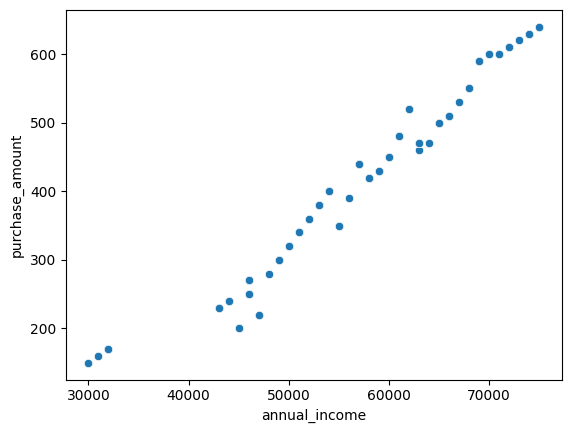

In [7]:
sns.histplot(df['annual_income'])
plt.show()

sns.scatterplot(x='annual_income', y='purchase_amount', data=df)
plt.show()


# Encode categorical (region)

In [8]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

#Feature Selection

In [9]:
features = df[['annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score']]

#Scaling

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

#Elbow Method

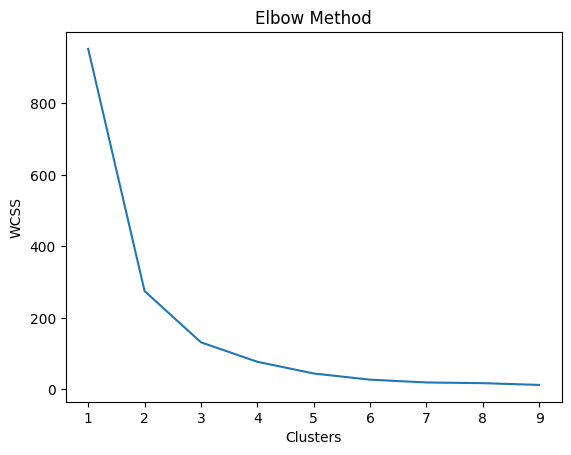

In [11]:
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()


#Apply K-Means (choose K=3 or 4 based on graph)

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

#Visualize Clusters

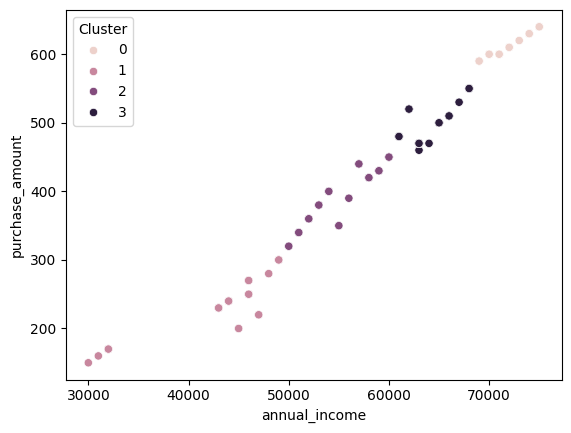

In [13]:
sns.scatterplot(x='annual_income', y='purchase_amount', hue='Cluster', data=df)
plt.show()

#Save Output

In [14]:
df.to_csv("/content/Customer.csv", index=False)